# Transient Response to Accumulation-Rate Changes

This notebook explores transient firn-model behavior when the nondimensional accumulation forcing `nu(t)` changes in time.

It uses `xarray_sweep` to evaluate a grid of forcing magnitudes and pulse durations.

**Note:** This notebook was created by Codex for exploratory purposes. Treat it as a starting point for analysis and validation, not as a finalized workflow.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from xarray_sweep import xarray_sweep

repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from main import FirnModel


/Users/jkingslake/Documents/science/firn_accumulation/firn_transient/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Forcing setup

We prescribe a pulse in nondimensional accumulation forcing:

- baseline: `nu(t) = 1`
- pulse: `nu(t) = 1 + delta` for `t_on <= t < t_on + pulse_duration`

The sweep dimensions are:

- `delta`: pulse magnitude
- `pulse_duration`: pulse duration


In [2]:
def run_pulse_case(delta=0.2, pulse_duration=1.0, t_on=2.0, simDuration=8.0):
    sim = FirnModel()

    def nu(t):
        t_arr = np.asarray(t)
        in_pulse = (t_arr >= t_on) & (t_arr < (t_on + pulse_duration))
        return 1.0 + delta * in_pulse.astype(float)

    out = sim.setup(
        nu=nu,
        interp_on_reg_z=True,
        simDuration=simDuration,
        print_messages=False,
    ).run()

    t_grid = np.linspace(0, simDuration, 401)
    out = out.interp(t=t_grid)

    out["h_anom"] = out["h"] - out["h"].isel(t=0)
    out["FAC_anom"] = out["FAC"] - out["FAC"].isel(t=0)
    out["z830_anom"] = out["z830"] - out["z830"].isel(t=0)

    return out


In [3]:
deltas = [0.1, 0.3, 0.5]
pulse_durations = [0.5, 1.5, 3.0]

sweep = xarray_sweep(
    run_pulse_case,
    delta=deltas,
    pulse_duration=pulse_durations,
)

sweep


100%|██████████| 9/9 [00:05<00:00,  1.68it/s]


<xarray.Dataset> Size: 42MB
Dimensions:         (delta: 3, pulse_duration: 3, z_h: 101, t: 401, z_r: 121)
Coordinates:
  * delta           (delta) float64 24B 0.1 0.3 0.5
  * pulse_duration  (pulse_duration) float64 24B 0.5 1.5 3.0
    z               (z_h, t, delta, pulse_duration) float64 3MB 0.0 ... 2.379
  * z_h             (z_h) float64 808B 0.0 0.01 0.02 0.03 ... 0.97 0.98 0.99 1.0
  * t               (t) float64 3kB 0.0 0.02 0.04 0.06 ... 7.94 7.96 7.98 8.0
  * z_r             (z_r) float64 968B 0.0 0.01 0.02 0.03 ... 1.17 1.18 1.19 1.2
Data variables: (12/20)
    phi             (z_h, t, delta, pulse_duration) float64 3MB 0.5 ... -9.77...
    r2              (z_h, t, delta, pulse_duration) float64 3MB 0.02857 ... 2...
    rho             (z_h, t, delta, pulse_duration) float64 3MB 459.0 ... 918.0
    A               (z_h, t, delta, pulse_duration) float64 3MB 0.0 ... 2.259
    T               (z_h, t, delta, pulse_duration) float64 3MB 0.0 0.0 ... 0.0
    w               (z_h, t, delta, pulse_duration) float64 3MB 2.0 2.0 ... 1.0
    ...              ...
    A_r             (z_r, t, delta, pulse_duration) float64 3MB 0.0 0.0 ... 1.08
    T_r             (z_r, t, delta, pulse_duration) float64 3MB 0.0 0.0 ... 0.0
    w_r             (z_r, t, delta, pulse_duration) float64 3MB 2.0 2.0 ... 1.0
    h_anom          (t, delta, pulse_duration) float64 29kB 0.0 0.0 ... 1.379
    FAC_anom        (t, delta, pulse_duration) float64 29kB 0.0 0.0 ... -12.45
    z830_anom       (t, delta, pulse_duration) float64 29kB 0.0 0.0 ... -0.4418
Attributes:
    simulation_parameters:  {'sim_label': 'default_label', 'b0_mpy': 0.1, 'be...

## Time-series response

Below, each panel corresponds to a pulse duration. Colored lines show different pulse magnitudes.


/var/folders/kl/3mt9f4qs1559xwy3mr60s7980000gp/T/ipykernel_33139/4150693428.py:10: FutureWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax, duration in zip(g.axes.flat, sweep.pulse_duration.values):


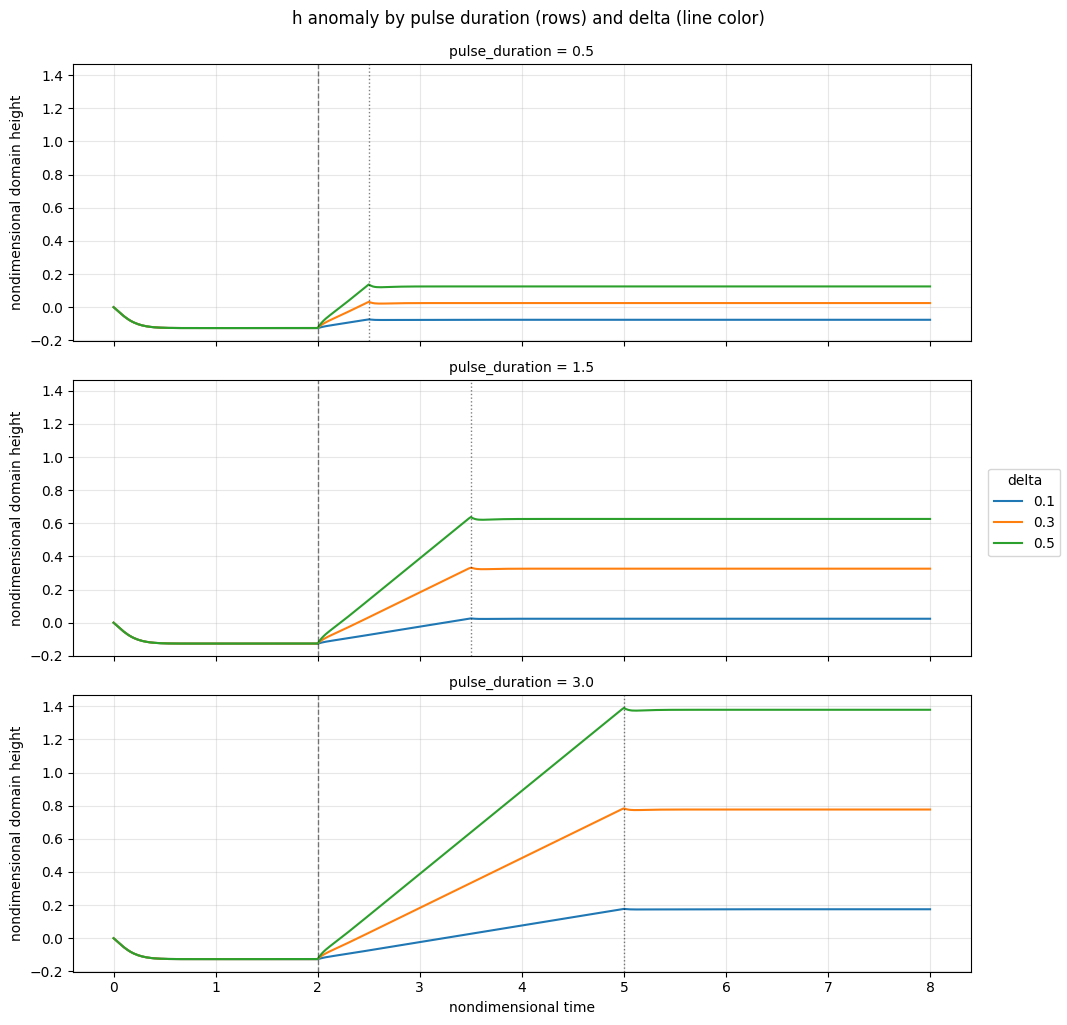

In [8]:
g = sweep.h_anom.plot.line(
    x="t",
    row="pulse_duration",
    hue="delta",
    figsize=(10, 10),
    add_legend=True,
)

g.fig.suptitle("h anomaly by pulse duration (rows) and delta (line color)", y=1.02)
for ax, duration in zip(g.axes.flat, sweep.pulse_duration.values):
    ax.axvline(2.0, color="k", ls="--", lw=1, alpha=0.5)
    ax.axvline(2.0 + float(duration), color="k", ls=":", lw=1, alpha=0.5)
    ax.grid(alpha=0.3)


## Compare multiple diagnostics


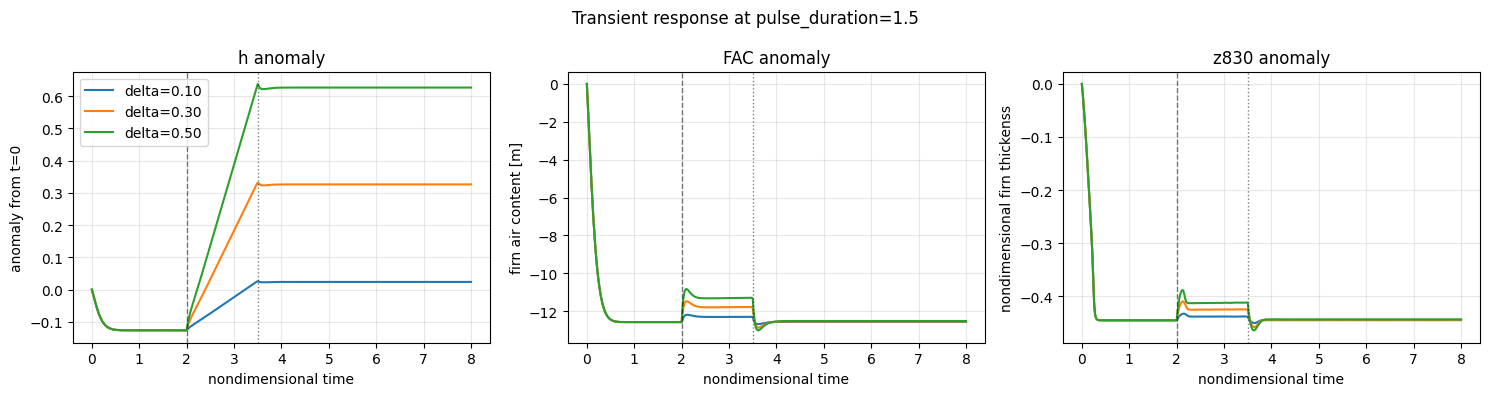

In [5]:
duration_to_show = 1.5

diag = sweep[["h_anom", "FAC_anom", "z830_anom"]].to_array("diagnostic")

g = diag.sel(pulse_duration=duration_to_show).plot.line(
    x="t",
    col="diagnostic",
    hue="delta",
    col_wrap=3,
    figsize=(14, 4),
    add_legend=True,
)

g.fig.suptitle(f"Transient diagnostics at pulse_duration={duration_to_show}", y=1.05)
for ax in g.axes.flat:
    ax.axvline(2.0, color="k", ls="--", lw=1, alpha=0.5)
    ax.axvline(2.0 + duration_to_show, color="k", ls=":", lw=1, alpha=0.5)
    ax.grid(alpha=0.3)


## Summary metrics across the sweep

- `peak_h_anom`: maximum height anomaly
- `peak_FAC_anom`: maximum FAC anomaly
- `t_peak_h`: time at maximum height anomaly


In [6]:
metrics = xr.Dataset()
metrics["peak_h_anom"] = sweep.h_anom.max("t")
metrics["peak_FAC_anom"] = sweep.FAC_anom.max("t")

idx_peak_h = sweep.h_anom.argmax("t")
metrics["t_peak_h"] = sweep.t.isel(t=idx_peak_h)

metrics


<xarray.Dataset> Size: 336B
Dimensions:         (delta: 3, pulse_duration: 3)
Coordinates:
  * delta           (delta) float64 24B 0.1 0.3 0.5
  * pulse_duration  (pulse_duration) float64 24B 0.5 1.5 3.0
    t               (delta, pulse_duration) float64 72B 0.0 3.5 5.0 ... 3.5 5.0
Data variables:
    peak_h_anom     (delta, pulse_duration) float64 72B 0.0 0.02587 ... 1.39
    peak_FAC_anom   (delta, pulse_duration) float64 72B 0.0 0.0 0.0 ... 0.0 0.0
    t_peak_h        (delta, pulse_duration) float64 72B 0.0 3.5 5.0 ... 3.5 5.0

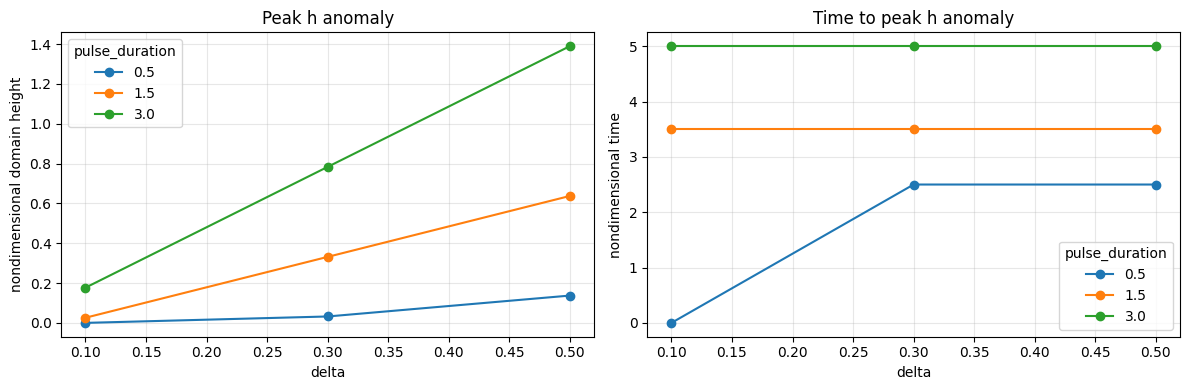

In [7]:
metrics.to_array("metric").plot.line(
    x="delta",
    hue="pulse_duration",
    col="metric",
    marker="o",
    col_wrap=2,
    figsize=(12, 4),
)


## Notes

- This focuses on transient response to nondimensional forcing changes through `nu(t)`.
- You can expand the sweep to include `beta`, `T_s_dim`, or grain-size parameters.
- For direct comparison to a baseline climate trajectory, add a `delta=0` control in `deltas`.


## Animation: regular-grid porosity with forcing timeline

This cell creates a GIF with `phi_r(z_r, t)` on top and `nu(t)` on the bottom,
including a moving vertical time marker.


In [11]:
from pathlib import Path
from matplotlib.animation import FuncAnimation, PillowWriter

DELTA = 0.5
PULSE_DURATION = 3.0
T_ON = 2.0
SIM_DURATION = 8.0
N_FRAMES = 160

sim = FirnModel()

def nu(t):
    t_arr = np.asarray(t)
    in_pulse = (t_arr >= T_ON) & (t_arr < (T_ON + PULSE_DURATION))
    return 1.0 + DELTA * in_pulse.astype(float)

out = sim.setup(
    nu=nu,
    interp_on_reg_z=True,
    simDuration=SIM_DURATION,
    print_messages=False,
).run()

if "phi_r" not in out:
    sim.interp_regular_z(var_name="phi")
    out = sim.results

t_anim = np.linspace(0.0, SIM_DURATION, N_FRAMES)
out_i = out.interp(t=t_anim)

phi_r = out_i["phi_r"].values
z_r = out_i["z_r"].values
fac_t = out_i["FAC"].values
nu_t = np.asarray(nu(t_anim), dtype=float)

fig, (ax_top, ax_mid, ax_bottom) = plt.subplots(
    3,
    1,
    figsize=(7, 9),
    gridspec_kw={"height_ratios": [3, 1, 1]},
)

(profile_line,) = ax_top.plot(phi_r[:, 0], z_r, lw=2.2, color="tab:green")
ax_top.invert_yaxis()
ax_top.set_xlabel("porosity, phi_r")
ax_top.set_ylabel("nondimensional regular depth, z_r")
ax_top.set_xlim(float(np.nanmin(phi_r)) - 0.02, float(np.nanmax(phi_r)) + 0.02)
ax_top.set_ylim(float(z_r.max()), float(z_r.min()))
ax_top.grid(alpha=0.3)
title = ax_top.set_title("")

phase_text = ax_top.text(
    0.02,
    0.02,
    "",
    transform=ax_top.transAxes,
    fontsize=10,
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
)

# Middle panel: FAC(t)
ax_mid.plot(t_anim, fac_t, color="tab:orange", lw=2)
(fac_marker,) = ax_mid.plot(
    [t_anim[0], t_anim[0]],
    [fac_t.min() - 0.05, fac_t.max() + 0.05],
    "r--",
    lw=1.8,
)
ax_mid.set_xlim(float(t_anim.min()), float(t_anim.max()))
ax_mid.set_ylim(float(fac_t.min() - 0.05), float(fac_t.max() + 0.05))
ax_mid.set_ylabel("FAC")
ax_mid.grid(alpha=0.3)

# Bottom panel: nu(t)
ax_bottom.plot(t_anim, nu_t, color="tab:blue", lw=2)
(time_marker,) = ax_bottom.plot(
    [t_anim[0], t_anim[0]],
    [nu_t.min() - 0.05, nu_t.max() + 0.05],
    "r--",
    lw=1.8,
)
ax_bottom.set_xlim(float(t_anim.min()), float(t_anim.max()))
ax_bottom.set_ylim(float(nu_t.min() - 0.05), float(nu_t.max() + 0.05))
ax_bottom.set_xlabel("nondimensional time")
ax_bottom.set_ylabel("nu(t)")
ax_bottom.grid(alpha=0.3)


def phase_label(t):
    if t < T_ON:
        return "pre-pulse"
    if t < T_ON + PULSE_DURATION:
        return "pulse active"
    return "post-pulse relaxation"


def update(i):
    t = t_anim[i]
    profile_line.set_data(phi_r[:, i], z_r)
    title.set_text(f"phi_r(z_r, t), t={t:.2f}")
    phase_text.set_text(
        f"delta={DELTA}, pulse_duration={PULSE_DURATION}\nphase: {phase_label(t)}"
    )
    fac_marker.set_data([t, t], [fac_t.min() - 0.05, fac_t.max() + 0.05])
    time_marker.set_data([t, t], [nu_t.min() - 0.05, nu_t.max() + 0.05])
    return profile_line, title, phase_text, fac_marker, time_marker

ani = FuncAnimation(fig, update, frames=N_FRAMES, interval=60, blit=False)

out_path = Path("figures/test.gif")
out_path.parent.mkdir(parents=True, exist_ok=True)
ani.save(out_path, writer=PillowWriter(fps=18))
plt.close(fig)

out_path


PosixPath('figures/test.gif')